# spatial neighbourhoods

In [1]:
import warnings
warnings.filterwarnings('ignore')
import scanpy as sc
import matplotlib.pyplot as plt 
import numpy as np
def spatial_neigbourshoods(anndata,
                           cluster_label = 'leiden_0.5',
                           max_distance_allowed = 200):
    
    import numpy as np
    import scanpy as sc
    import pandas as pd
    from sklearn.metrics.pairwise import euclidean_distances
    
    distances_input=np.array([anndata.obs['x_centroid'],anndata.obs['y_centroid']])
    din=distances_input.transpose()
    distances=euclidean_distances(din, din)
    dist_df=pd.DataFrame(distances)
    max_distance_allowed=max_distance_allowed
    dist_binary=((dist_df<max_distance_allowed)*1)*((dist_df!=
                                                     0)*1)
    np.sum(np.sum(dist_binary))
    dist_binary['name']=list(anndata.obs[cluster_label])
    distbinsum=dist_binary.groupby('name').sum()
    adata=sc.AnnData(distbinsum.transpose())
    adata.obs=anndata.obs

    return adata


In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation.h5ad')

# run spatial neigbourshoods

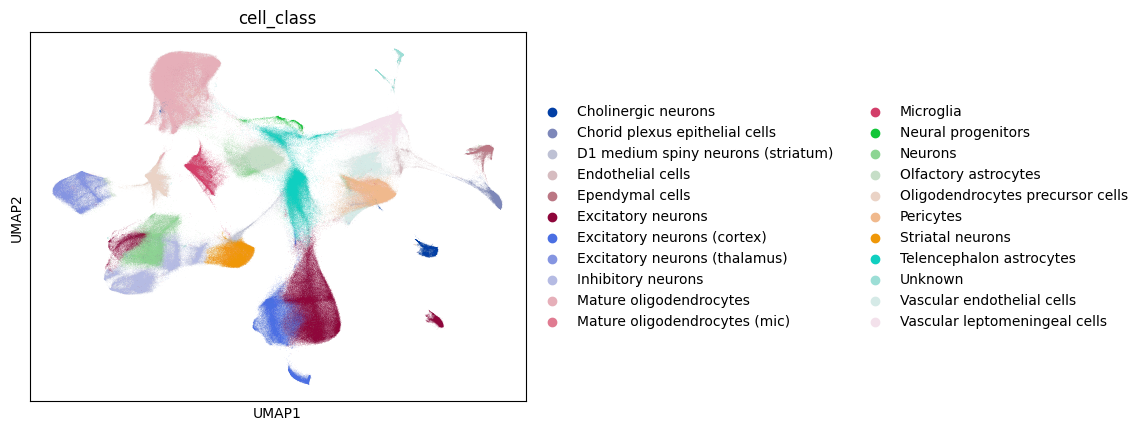

In [3]:
sc.pl.umap(adata, color = 'cell_class')

In [4]:
adata.obs.sample_id.unique()

['RB4282', 'RB4350', 'RB4401', 'RB4403', 'RB4405', ..., 'RB4627', 'RB4630', 'RB4653', 'RB4658', 'RB4676']
Length: 12
Categories (12, object): ['RB4282', 'RB4350', 'RB4401', 'RB4403', ..., 'RB4630', 'RB4653', 'RB4658', 'RB4676']

In [ ]:
ad_sn_list = []
for i in ['RB4405']:
    print(i)
    ad_sub_sample = adata[adata.obs['sample_id'] == i]
    ad_sn = spatial_neigbourshoods(anndata = ad_sub_sample, cluster_label = 'cell_class',max_distance_allowed = 500) #50 #600 #200#550
    ad_sn_list.append(ad_sn)

RB4405


In [7]:
ad_sub_sample

View of AnnData object with n_obs × n_vars = 81721 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'